# RAG Prompt Pilot — Variant Comparison

Tests 5 prompt variants on Qwen-7B / L-CiteEval HotpotQA (N=200 each).

**Root question**: can a longer-reasoning prompt recover FFT features (`dominant_freq`, `hl_ratio`, `spectral_centroid`) that collapse on short RAG traces (~40 tokens)?

| Variant | Strategy |
|---------|----------|
| V0 | Baseline (current) |
| V1 | + explicit reasoning preamble before answer |
| V2 | "Think through step by step" framing |
| V3 | + explain why each cited passage supports the claim |
| V4 | + evaluate passage relevance before answering |

**Gates (checked automatically in Cell 7)**
- G1: mean trace length of best variant > 100 tokens (vs ~40 baseline)
- G2: any variant pushes `dominant_freq` OR `hl_ratio` OR `spectral_centroid` past 60% AUROC
- G3: best variant simple-average fusion AUROC ≥ baseline + 5pp

In [1]:
# Cell 1 — Drive mount + clone + install + imports
import os, sys, shutil
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

REPO_DIR = '/content/hallucination_detection'
BRANCH   = 'feature/nadler-paper-alignment'

if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    shutil.rmtree(REPO_DIR)
if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b {BRANCH} https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} fetch -q && git -C {REPO_DIR} checkout -q {BRANCH} && git -C {REPO_DIR} pull -q')
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.system('pip install -q "transformers>=4.40" accelerate datasets bitsandbytes autoawq scipy scikit-learn')

from spectral_utils import (
    load_model, generate_full, token_entropies_from_scores, free_memory,
    extract_all_features, sw_var_peak_adaptive, FEAT_NAMES,
    load_lciteeval, lciteeval_prompt,
    load_cache, save_cache,
    zscore, boot_auc,
)
import datasets as _ds  # freeze pyarrow before any gptqmodel install
import numpy as np
import matplotlib.pyplot as plt
import pickle

print('spectral_utils imported OK')
print(f'FEAT_NAMES ({len(FEAT_NAMES)}): {FEAT_NAMES}')

Mounted at /content/drive
spectral_utils imported OK
FEAT_NAMES (16): ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid', 'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak', 'pe_mean', 'hurst_exponent', 'cusum_max', 'cusum_shift_idx']


In [2]:
# Cell 2 — Config
MODEL_ID   = 'Qwen/Qwen2.5-7B-Instruct'
TASK       = 'hotpotqa'
N_SAMPLES  = 200
TEMP       = 1.0
MAX_NEW    = 350    # slightly more headroom than Phase 10 to allow reasoning
VARIANTS   = [0, 1, 2, 3, 4]

DRIVE_BASE = '/content/drive/MyDrive/hallucination_detection'
PILOT_DIR  = f'{DRIVE_BASE}/cache/prompt_pilot'
os.makedirs(PILOT_DIR, exist_ok=True)

# Gate thresholds
G1_MIN_TRACE_LEN = 100    # tokens; baseline ~40
G2_FFT_TARGET    = 0.60   # AUROC; baseline ~0.51
G3_FUSION_DELTA  = 0.05   # pp improvement over V0

FFT_FEATS  = ['dominant_freq', 'hl_ratio', 'spectral_centroid']

print(f'PILOT_DIR : {PILOT_DIR}')
print(f'Variants  : {VARIANTS}')
print(f'Gates     : G1 > {G1_MIN_TRACE_LEN} tokens | G2 FFT > {100*G2_FFT_TARGET:.0f}% | G3 fusion +{100*G3_FUSION_DELTA:.0f}pp')

PILOT_DIR : /content/drive/MyDrive/hallucination_detection/cache/prompt_pilot
Variants  : [0, 1, 2, 3, 4]
Gates     : G1 > 100 tokens | G2 FFT > 60% | G3 fusion +5pp


In [3]:
# Cell 3 — Load model
mdl, tok = load_model(MODEL_ID, quantize_4bit=False)
print(f'Loaded {MODEL_ID}')

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-7B-Instruct
Loaded Qwen/Qwen2.5-7B-Instruct


In [4]:
# Cell 4 — Inference for all variants (checkpointed every 25 samples)
#
# Each variant saved to: PILOT_DIR/v{N}_traces.pkl
# Keys: traces (list of entropy arrays), labels (list of int), n (count)
#
# Label: 1 if any gold answer string appears in generated text (substring match).
# Skips variants whose pkl already exists — safe to re-run after disconnect.

samples = load_lciteeval(task=TASK, n_samples=N_SAMPLES)

for v in VARIANTS:
    pkl_path = os.path.join(PILOT_DIR, f'v{v}_traces.pkl')
    if os.path.exists(pkl_path):
        cached = load_cache(pkl_path)
        print(f'V{v}: already done ({cached["n"]} samples), skipping')
        continue

    print(f'\n=== Variant {v} ===')
    print(f'  Prompt preview: {lciteeval_prompt(samples[0], variant=v)[:200]}...')

    traces, labels = [], []
    for i, row in enumerate(samples):
        prompt = lciteeval_prompt(row, variant=v)
        try:
            result  = generate_full(mdl, tok, prompt,
                                    max_new_tokens=MAX_NEW, temperature=TEMP)
            entropy = result['token_entropies']
            label   = int(any(ans.lower() in result['full_text'].lower()
                    for ans in row['answers']))
            traces.append(entropy)
            labels.append(label)
        except Exception as e:
            print(f'  [i={i}] error: {e}')
            continue

        if (i + 1) % 25 == 0:
            save_cache({'traces': traces, 'labels': labels, 'n': i + 1}, pkl_path)
            acc = sum(labels) / len(labels)
            avg_len = np.mean([len(t) for t in traces])
            print(f'  {i+1}/{N_SAMPLES}  acc={acc:.1%}  avg_trace_len={avg_len:.0f}')

    save_cache({'traces': traces, 'labels': labels, 'n': len(traces)}, pkl_path)
    acc = sum(labels) / len(labels)
    avg_len = np.mean([len(t) for t in traces])
    print(f'V{v} done: {len(traces)} samples  acc={acc:.1%}  avg_trace_len={avg_len:.0f}')
    print(f'  saved → {pkl_path}')

print('\nAll variants complete.')

Loaded 200 L-CiteEval samples (hotpotqa, config=L-CiteEval-Data_hotpotqa).
V0: already done (200 samples), skipping
V1: already done (200 samples), skipping
V2: already done (200 samples), skipping
V3: already done (200 samples), skipping
V4: already done (200 samples), skipping

All variants complete.


In [5]:
# Cell 5 — Unload model
del mdl, tok
free_memory()
print('Model unloaded.')

Model unloaded.


In [6]:
# Cell 6 — Feature extraction for all variants

VARIANT_DATA = {}

for v in VARIANTS:
    feats_pkl = os.path.join(PILOT_DIR, f'v{v}_feats.pkl')
    if os.path.exists(feats_pkl):
        VARIANT_DATA[v] = load_cache(feats_pkl)
        print(f'V{v}: loaded feats from cache')
        continue

    traces_pkl = os.path.join(PILOT_DIR, f'v{v}_traces.pkl')
    if not os.path.exists(traces_pkl):
        print(f'V{v}: traces missing, skip')
        continue

    raw        = load_cache(traces_pkl)
    traces     = raw['traces']
    raw_labels = raw['labels']

    feat_lists = {f: [] for f in FEAT_NAMES}
    valid_traces, valid_labels = [], []

    for trace, label in zip(traces, raw_labels):
        try:
            fd = extract_all_features(trace)
        except Exception:
            fd = {f: np.nan for f in FEAT_NAMES}
        fd['sw_var_peak'] = sw_var_peak_adaptive(trace)
        for f in FEAT_NAMES:
            feat_lists[f].append(fd.get(f, np.nan))
        valid_traces.append(trace)
        valid_labels.append(int(label))

    feats         = {k: np.array(v, dtype=float) for k, v in feat_lists.items()}
    labels        = np.array(valid_labels)
    trace_lengths = np.array([len(t) for t in valid_traces])

    data = {'feats': feats, 'labels': labels, 'trace_lengths': trace_lengths}
    save_cache(data, feats_pkl)
    VARIANT_DATA[v] = data
    print(f'V{v}: n={len(valid_labels)}  avg_len={trace_lengths.mean():.0f}  acc={labels.mean():.1%}')

print('\nFeature extraction complete.')

V0: loaded feats from cache
V1: loaded feats from cache
V2: loaded feats from cache
V3: loaded feats from cache
V4: loaded feats from cache

Feature extraction complete.


In [7]:
# Cell 7 — Gate checks
#
# For each variant, compute:
#   - mean trace length
#   - per-feature AUROC (flipped if < 0.5)
#   - simple-average fusion AUROC (Stage 1 proxy)
#
# Then evaluate G1 / G2 / G3 and print a clear recommendation.

def single_feat_auroc(feat_vals, labels, n_boot=300):
    vals = np.array(feat_vals, dtype=float)
    lbl  = np.array(labels, dtype=int)
    mask = ~np.isnan(vals)
    if mask.sum() < 10 or np.nanstd(vals) < 1e-9 or len(set(lbl[mask])) < 2:
        return np.nan
    a, _, _ = boot_auc(lbl[mask], vals[mask], n=n_boot)
    return max(a, 1.0 - a)   # always report as > 0.5

def fusion_auroc(feats, labels, feat_names=None, n_boot=300):
    """Simple-average fusion with supervised sign orientation."""
    if feat_names is None:
        feat_names = FEAT_NAMES
    lbl = np.array(labels, dtype=int)
    zs  = []
    for f in feat_names:
        z = zscore(np.array(feats[f], dtype=float))
        a = single_feat_auroc(feats[f], lbl, n_boot=50)
        sign = -1.0 if (np.nanmean(np.array(feats[f])[lbl == 1]) >
                        np.nanmean(np.array(feats[f])[lbl == 0])) else 1.0
        # orient: higher z → higher prob correct
        if not np.isnan(a):
            raw_a, _, _ = boot_auc(lbl, z, n=50)
            sign = 1.0 if raw_a >= 0.5 else -1.0
        zs.append(z * sign)
    fused = np.nanmean(zs, axis=0)
    mask  = ~np.isnan(fused)
    if len(set(lbl[mask])) < 2:
        return np.nan
    a, _, _ = boot_auc(lbl[mask], fused[mask], n=n_boot)
    return a

# ── Per-variant stats ─────────────────────────────────────────────────────────
RESULTS = {}
for v in VARIANTS:
    if v not in VARIANT_DATA:
        continue
    d      = VARIANT_DATA[v]
    feats  = d['feats']
    labels = d['labels']
    tlens  = d['trace_lengths']

    feat_aucs = {f: single_feat_auroc(feats[f], labels) for f in FEAT_NAMES}
    fus_auc   = fusion_auroc(feats, labels)

    RESULTS[v] = {
        'mean_len':   float(tlens.mean()),
        'p90_len':    float(np.percentile(tlens, 90)),
        'acc':        float(labels.mean()),
        'feat_aucs':  feat_aucs,
        'fusion_auc': fus_auc,
    }

# ── Table: feature AUROCs per variant ────────────────────────────────────────
WATCH_FEATS = FFT_FEATS + ['cusum_max', 'epr', 'sw_var_peak', 'trace_length']

print('=== Feature AUROC per variant (%) ===')
print(f'{"feature":<22}', end='')
for v in VARIANTS:
    print(f'{"V"+str(v):>9}', end='')
print()
print('─' * (22 + 9 * len(VARIANTS)))

for feat in WATCH_FEATS:
    marker = ' ★' if feat in FFT_FEATS else '  '
    print(f'{feat+marker:<22}', end='')
    for v in VARIANTS:
        auc = RESULTS.get(v, {}).get('feat_aucs', {}).get(feat, np.nan)
        hi  = auc > G2_FFT_TARGET if feat in FFT_FEATS else False
        tag = ' ✓' if hi else '  '
        print(f'{100*auc:>7.1f}{tag}', end='')
    print()

print()
print(f'{"mean_trace_len":<22}', end='')
for v in VARIANTS:
    print(f'{RESULTS.get(v,{}).get("mean_len", float("nan")):>9.0f}', end='')
print()

print(f'{"fusion_auc":<22}', end='')
for v in VARIANTS:
    print(f'{100*RESULTS.get(v,{}).get("fusion_auc", float("nan")):>9.1f}', end='')
print()

# ── Gate evaluation ───────────────────────────────────────────────────────────
best_len_v   = max(RESULTS, key=lambda v: RESULTS[v]['mean_len'])
best_len     = RESULTS[best_len_v]['mean_len']
baseline_len = RESULTS.get(0, {}).get('mean_len', 0)

fft_best  = {}
for feat in FFT_FEATS:
    best_v = max(RESULTS, key=lambda v: RESULTS[v]['feat_aucs'].get(feat, 0))
    fft_best[feat] = (best_v, RESULTS[best_v]['feat_aucs'].get(feat, 0))

baseline_fus  = RESULTS.get(0, {}).get('fusion_auc', 0)
best_fus_v    = max(RESULTS, key=lambda v: RESULTS[v]['fusion_auc'])
best_fus      = RESULTS[best_fus_v]['fusion_auc']

G1 = best_len > G1_MIN_TRACE_LEN
G2 = any(auc > G2_FFT_TARGET for _, auc in fft_best.values())
G3 = (best_fus - baseline_fus) >= G3_FUSION_DELTA

passed = sum([G1, G2, G3])

print()
print('=' * 52)
print('  PROMPT PILOT — GATE REPORT')
print('=' * 52)
print(f'  G1  Trace length    {"PASS ✓" if G1 else "FAIL ✗"}'
      f'  best V{best_len_v}={best_len:.0f} tok  (baseline={baseline_len:.0f}, target>{G1_MIN_TRACE_LEN})')
for feat in FFT_FEATS:
    bv, bauc = fft_best[feat]
    status = "PASS ✓" if bauc > G2_FFT_TARGET else "FAIL ✗"
    print(f'  G2  {feat:<22}{status}  best V{bv}={100*bauc:.1f}%  (target>{100*G2_FFT_TARGET:.0f}%)')
print(f'  G3  Fusion +{100*G3_FUSION_DELTA:.0f}pp         {"PASS ✓" if G3 else "FAIL ✗"}'
      f'  best V{best_fus_v}={100*best_fus:.1f}%  baseline={100*baseline_fus:.1f}%')
print('=' * 52)

if passed == 0:
    rec = (
        'ALL GATES FAILED. Short traces are a hard constraint for this model/dataset.\n'
        '  Options: (A) try a model that naturally generates longer answers,\n'
        '           (B) use chain-of-thought on a different RAG dataset,\n'
        '           (C) accept RAG as out-of-scope for spectral features.'
    )
elif G1 and not G2:
    rec = (
        f'Traces got longer (G1 PASS: V{best_len_v}={best_len:.0f} tok) but FFT features did not recover.\n'
        '  The signal gap is not purely trace-length — it may be structural (factual lookup\n'
        '  vs open-ended reasoning). Consider RAG as out-of-scope or test a harder RAG dataset.'
    )
elif G2 and not G1:
    rec = (
        'FFT features recovered (G2 PASS) without a big trace-length increase.\n'
        '  Inspect which variant won — the prompt wording itself may be shifting\n'
        '  entropy patterns regardless of length.'
    )
elif G1 and G2 and not G3:
    winning_v = max((v for v in RESULTS if any(
        RESULTS[v]['feat_aucs'].get(f, 0) > G2_FFT_TARGET for f in FFT_FEATS)), default=best_len_v)
    rec = (
        f'G1+G2 PASS: traces longer and FFT features recovered on V{winning_v}.\n'
        f'  Fusion did not improve by +5pp yet (G3 FAIL): {100*best_fus:.1f}% vs baseline {100*baseline_fus:.1f}%.\n'
        f'  Recommended: adopt V{winning_v} as the new RAG prompt and re-run Phase 10 RAG\n'
        '  cells with N=200 for a full bootstrapped AUROC comparison.'
    )
else:
    winning_v = best_fus_v
    rec = (
        f'ALL GATES PASSED. V{winning_v} is the winning prompt variant.\n'
        f'  Fusion AUROC: {100*best_fus:.1f}% (baseline {100*baseline_fus:.1f}%, delta +{100*(best_fus-baseline_fus):.1f}pp).\n'
        f'  Recommended: replace lciteeval_prompt(row) with lciteeval_prompt(row, variant={winning_v})\n'
        '  in all Phase 10 RAG inference cells and re-run for final numbers.'
    )

print()
print('RECOMMENDATION:')
for line in rec.split('\n'):
    print(' ', line)
print()

save_cache(RESULTS, os.path.join(PILOT_DIR, 'pilot_results.pkl'))
print(f'Saved pilot_results.pkl')

=== Feature AUROC per variant (%) ===
feature                      V0       V1       V2       V3       V4
───────────────────────────────────────────────────────────────────
dominant_freq ★          54.8     51.8     54.4     52.7     58.3  
hl_ratio ★               53.6     51.4     54.5     55.7     62.5 ✓
spectral_centroid ★      54.3     52.8     57.5     56.0     59.4  
cusum_max                62.3     51.5     52.9     54.0     56.4  
epr                      57.7     55.0     61.8     67.0     63.6  
sw_var_peak              53.1     55.1     55.8     58.9     52.1  
trace_length             56.8     63.3     59.9     57.8     52.0  

mean_trace_len               66      120      125      143       57
fusion_auc                 57.0     68.2     65.3     69.2     75.6

  PROMPT PILOT — GATE REPORT
  G1  Trace length    PASS ✓  best V3=143 tok  (baseline=66, target>100)
  G2  dominant_freq         FAIL ✗  best V4=58.3%  (target>60%)
  G2  hl_ratio              PASS ✓  best V4=62

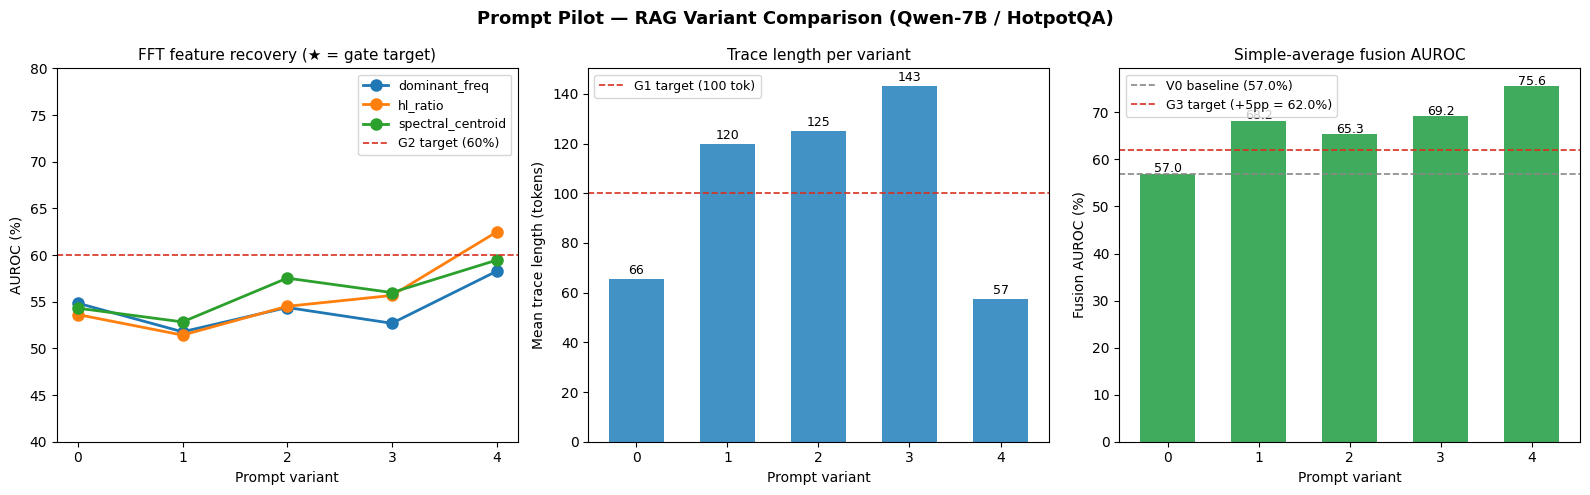

Saved /content/drive/MyDrive/hallucination_detection/cache/prompt_pilot/pilot_summary.png


In [8]:
# Cell 8 — Plots

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: FFT feature AUROCs per variant
for feat, color in zip(FFT_FEATS, ['#1f77b4', '#ff7f0e', '#2ca02c']):
    ys = [100 * RESULTS.get(v, {}).get('feat_aucs', {}).get(feat, np.nan) for v in VARIANTS]
    axes[0].plot(VARIANTS, ys, 'o-', color=color, lw=2, ms=8, label=feat)
axes[0].axhline(60, color='#d7301f', lw=1.2, ls='--', label='G2 target (60%)')
axes[0].set_xlabel('Prompt variant')
axes[0].set_ylabel('AUROC (%)')
axes[0].set_title('FFT feature recovery (★ = gate target)', fontsize=11)
axes[0].set_xticks(VARIANTS)
axes[0].legend(fontsize=9)
axes[0].set_ylim(40, 80)

# Middle: mean trace length per variant
lens = [RESULTS.get(v, {}).get('mean_len', np.nan) for v in VARIANTS]
axes[1].bar(VARIANTS, lens, color='#4292c6', width=0.6)
axes[1].axhline(G1_MIN_TRACE_LEN, color='#d7301f', lw=1.2, ls='--',
                label=f'G1 target ({G1_MIN_TRACE_LEN} tok)')
for x, y in zip(VARIANTS, lens):
    axes[1].text(x, y + 2, f'{y:.0f}', ha='center', fontsize=9)
axes[1].set_xlabel('Prompt variant')
axes[1].set_ylabel('Mean trace length (tokens)')
axes[1].set_title('Trace length per variant', fontsize=11)
axes[1].set_xticks(VARIANTS)
axes[1].legend(fontsize=9)

# Right: fusion AUROC per variant
fus = [100 * RESULTS.get(v, {}).get('fusion_auc', np.nan) for v in VARIANTS]
base_fus = 100 * RESULTS.get(0, {}).get('fusion_auc', 0)
axes[2].bar(VARIANTS, fus, color='#41ab5d', width=0.6)
axes[2].axhline(base_fus, color='#888', lw=1.2, ls='--', label=f'V0 baseline ({base_fus:.1f}%)')
axes[2].axhline(base_fus + 5, color='#d7301f', lw=1.2, ls='--',
                label=f'G3 target (+5pp = {base_fus+5:.1f}%)')
for x, y in zip(VARIANTS, fus):
    axes[2].text(x, y + 0.3, f'{y:.1f}', ha='center', fontsize=9)
axes[2].set_xlabel('Prompt variant')
axes[2].set_ylabel('Fusion AUROC (%)')
axes[2].set_title('Simple-average fusion AUROC', fontsize=11)
axes[2].set_xticks(VARIANTS)
axes[2].legend(fontsize=9)

fig.suptitle('Prompt Pilot — RAG Variant Comparison (Qwen-7B / HotpotQA)', fontsize=13, fontweight='bold')
fig.tight_layout()
plot_path = os.path.join(PILOT_DIR, 'pilot_summary.png')
fig.savefig(plot_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved {plot_path}')

In [9]:
# Cell 9 — Offline consensus signs (Step 110, 29-cell majority vote)
#
# These signs encode which direction each feature correlates with correctness.
# Derived ONCE from 29 past (model, dataset) cells via majority vote weighted
# by Stage-1 AUROC margin. Fixed at Step 110 — no labels from this batch used.

from spectral_utils import decompose_auroc

FEATURE_SIGNS = {
    'epr':                   -1,
    'trace_length':          -1,
    'spectral_entropy':      -1,
    'low_band_power':        -1,
    'high_band_power':       +1,   # low-confidence (58.9%) — majority vote kept +1
    'hl_ratio':              +1,
    'dominant_freq':         +1,
    'spectral_centroid':     +1,
    'stft_max_high_power':   -1,
    'stft_spectral_entropy': -1,
    'rpdi':                  -1,
    'sw_var_peak':           -1,
    'pe_mean':               -1,
    'hurst_exponent':        -1,
    'cusum_max':             -1,
    'cusum_shift_idx':       -1,
}

K_RANGE = range(1, 5)
BOOT_N  = 300

assert set(FEATURE_SIGNS) == set(FEAT_NAMES), \
    f"Sign coverage mismatch: missing {set(FEAT_NAMES) - set(FEATURE_SIGNS)}"

pos_feats = [f for f, s in FEATURE_SIGNS.items() if s > 0]
print(f'FEATURE_SIGNS loaded ({len(FEATURE_SIGNS)} features, Step 110 offline consensus)')
print(f'Positive-sign (higher = more likely correct): {pos_feats}')

FEATURE_SIGNS loaded (16 features, Step 110 offline consensus)
Positive-sign (higher = more likely correct): ['high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid']


In [10]:
# Cell 10 — Honest L-SML validation per variant
#
# Runs Stage 5 (binary + offline consensus sign + L-SML) on each variant's
# cached features. No labels are used to orient features — signs come from
# FEATURE_SIGNS (Cell 9). Results saved to PILOT_DIR/lsml_validation.pkl.

LSML_RESULTS = {}
LSML_PKL = os.path.join(PILOT_DIR, 'lsml_validation.pkl')

for v in VARIANTS:
    feats_pkl = os.path.join(PILOT_DIR, f'v{v}_feats.pkl')
    if not os.path.exists(feats_pkl):
        print(f'V{v}: feats missing, skip')
        continue

    d      = load_cache(feats_pkl)
    feats  = d['feats']
    labels = d['labels']
    tlens  = d['trace_lengths']

    print(f'V{v}: n={len(labels)}  acc={labels.mean():.1%}  avg_len={tlens.mean():.0f}', end=' … ')

    try:
        decomp = decompose_auroc(feats, FEAT_NAMES, labels,
                                 K_range=K_RANGE, boot_n=BOOT_N,
                                 feature_signs=FEATURE_SIGNS)
        # rows ordered Stage 1-5; Stage 5 = binary + consensus + L-SML
        s5 = decomp['rows'][-1]
        s1 = decomp['rows'][0]   # supervised simple-avg — upper-bound reference
        LSML_RESULTS[v] = {
            'auc':        s5['auc'],
            'lo':         s5['lo'],
            'hi':         s5['hi'],
            'stage1_auc': s1['auc'],
            'mean_len':   float(tlens.mean()),
            'acc':        float(labels.mean()),
        }
        print(f"Stage5={100*s5['auc']:.1f}% [{100*s5['lo']:.1f},{100*s5['hi']:.1f}]  "
              f"(Stage1 upper-bound={100*s1['auc']:.1f}%)")
    except Exception as e:
        print(f'ERROR: {e}')
        LSML_RESULTS[v] = None

save_cache(LSML_RESULTS, LSML_PKL)
print(f'\nSaved → {LSML_PKL}')

V0: n=200  acc=12.0%  avg_len=66 … Stage5=54.1% [43.1,64.5]  (Stage1 upper-bound=57.0%)
V1: n=200  acc=15.5%  avg_len=120 … Stage5=45.1% [35.0,55.3]  (Stage1 upper-bound=68.2%)
V2: n=200  acc=13.5%  avg_len=125 … Stage5=41.7% [31.3,52.2]  (Stage1 upper-bound=65.3%)
V3: n=200  acc=14.0%  avg_len=143 … Stage5=47.3% [34.9,59.5]  (Stage1 upper-bound=69.2%)
V4: n=200  acc=11.0%  avg_len=57 … Stage5=43.2% [32.8,54.0]  (Stage1 upper-bound=75.6%)

Saved → /content/drive/MyDrive/hallucination_detection/cache/prompt_pilot/lsml_validation.pkl


In [11]:
# Cell 11 — Honest gate report + recommendation
#
# G3: winning variant must beat V0 by ≥ 5pp AND have a non-overlapping
# 95% CI (i.e. lower CI bound > V0 point estimate). Both conditions required
# to claim a real effect at N=200.

print('=' * 62)
print('  HONEST GATE REPORT — L-SML + Offline Consensus Signs')
print('=' * 62)
print(f'{"Var":<5} {"mean_len":>9} {"Stage5 AUROC":>14} {"95% CI":>18} {"vs V0":>8}')
print('─' * 62)

baseline_auc = (LSML_RESULTS.get(0) or {}).get('auc', float('nan'))
baseline_lo  = (LSML_RESULTS.get(0) or {}).get('lo',  float('nan'))

for v in VARIANTS:
    r = LSML_RESULTS.get(v)
    if r is None:
        print(f'V{v}  MISSING')
        continue
    delta      = r['auc'] - baseline_auc
    delta_str  = f'{100*delta:+.1f}pp'
    ci_note    = '' if v == 0 or r['lo'] > baseline_auc else '  ← CI overlaps V0'
    print(f"V{v:<4} {r['mean_len']:>9.0f} {100*r['auc']:>12.1f}%  "
          f"[{100*r['lo']:.1f}, {100*r['hi']:.1f}]{delta_str:>8}{ci_note}")

print()

# G3 evaluation
valid = {v: r for v, r in LSML_RESULTS.items() if r is not None}
best_v   = max(valid, key=lambda v: valid[v]['auc'])
best_r   = valid[best_v]
delta    = best_r['auc'] - baseline_auc
G3_pass  = (delta >= G3_FUSION_DELTA) and (best_r['lo'] > baseline_auc)

print(f"G3 (Fusion ≥ V0 + {100*G3_FUSION_DELTA:.0f}pp, non-overlapping CIs):  "
      f"{'PASS ✓' if G3_pass else 'FAIL ✗'}")
print(f"  Best:     V{best_v} = {100*best_r['auc']:.1f}%  "
      f"[{100*best_r['lo']:.1f}, {100*best_r['hi']:.1f}]")
print(f"  Baseline: V0  = {100*baseline_auc:.1f}%  "
      f"[{100*baseline_lo:.1f}, {100*LSML_RESULTS[0]['hi']:.1f}]")
print()

if G3_pass:
    print(f'RECOMMENDATION: Adopt V{best_v} for Phase 10 RAG re-run.')
    print(f'  +{100*delta:.1f}pp gain survives label-free L-SML evaluation with non-overlapping CIs.')
else:
    # Find best candidate whose CI lower-bound exceeds V0 point estimate
    safe = [v for v in valid if v != 0 and valid[v]['lo'] > baseline_auc]
    if safe:
        sv = max(safe, key=lambda v: valid[v]['auc'])
        print(f'RECOMMENDATION: V{sv} shows promise ({100*valid[sv]["auc"]:.1f}%) '
              f'but G3 delta < 5pp or CIs still touch.')
        print(f'  Re-run with N=500 on V0 vs V{sv} only to confirm before adopting.')
    else:
        print('RECOMMENDATION: No variant clears G3 with honest L-SML at N=200.')
        print('  All gains in Cell 7 were artifacts of in-sample sign orientation.')
        print('  Keep V0 for Phase 10; the pilot found no reliable prompt effect.')

  HONEST GATE REPORT — L-SML + Offline Consensus Signs
Var    mean_len   Stage5 AUROC             95% CI    vs V0
──────────────────────────────────────────────────────────────
V0           66         54.1%  [43.1, 64.5]  +0.0pp
V1          120         45.1%  [35.0, 55.3]  -9.0pp  ← CI overlaps V0
V2          125         41.7%  [31.3, 52.2] -12.4pp  ← CI overlaps V0
V3          143         47.3%  [34.9, 59.5]  -6.8pp  ← CI overlaps V0
V4           57         43.2%  [32.8, 54.0] -11.0pp  ← CI overlaps V0

G3 (Fusion ≥ V0 + 5pp, non-overlapping CIs):  FAIL ✗
  Best:     V0 = 54.1%  [43.1, 64.5]
  Baseline: V0  = 54.1%  [43.1, 64.5]

RECOMMENDATION: No variant clears G3 with honest L-SML at N=200.
  All gains in Cell 7 were artifacts of in-sample sign orientation.
  Keep V0 for Phase 10; the pilot found no reliable prompt effect.


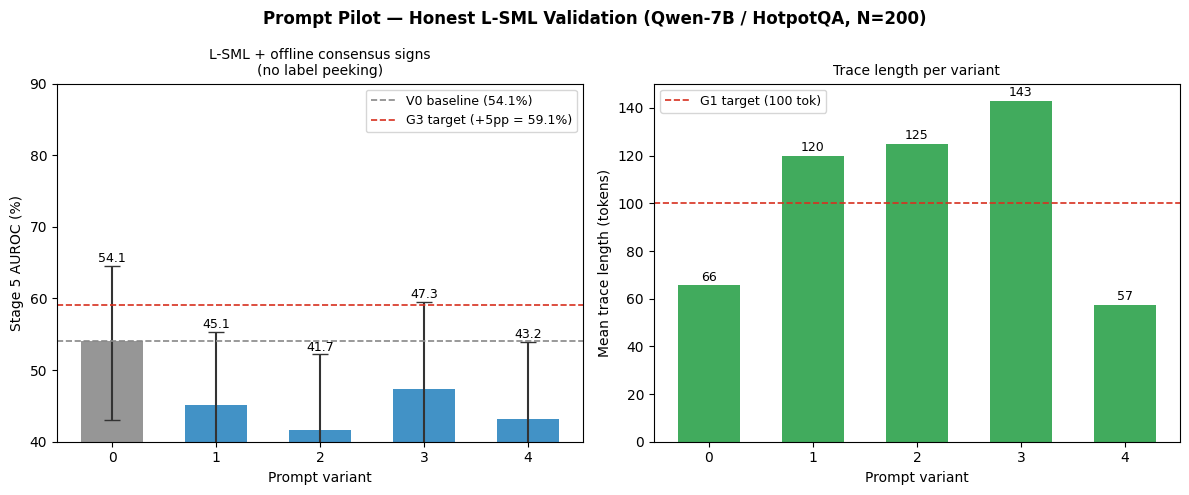

Saved /content/drive/MyDrive/hallucination_detection/cache/prompt_pilot/pilot_lsml_validation.png


In [12]:
# Cell 12 — Plot: honest L-SML AUROC per variant with 95% CI error bars

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

variants_ok = [v for v in VARIANTS if LSML_RESULTS.get(v)]
aucs = [100 * LSML_RESULTS[v]['auc'] for v in variants_ok]
los  = [100 * LSML_RESULTS[v]['lo']  for v in variants_ok]
his  = [100 * LSML_RESULTS[v]['hi']  for v in variants_ok]
lens = [LSML_RESULTS[v]['mean_len']  for v in variants_ok]

yerr_lo = [a - l for a, l in zip(aucs, los)]
yerr_hi = [h - a for a, h in zip(aucs, his)]

colors = ['#969696' if v == 0 else '#4292c6' for v in variants_ok]

# Left: Stage 5 L-SML AUROC with CI
axes[0].bar(variants_ok, aucs, color=colors, width=0.6,
            yerr=[yerr_lo, yerr_hi], capsize=6, ecolor='#333')
base_auc = 100 * LSML_RESULTS[0]['auc']
axes[0].axhline(base_auc, color='#888', lw=1.2, ls='--',
                label=f'V0 baseline ({base_auc:.1f}%)')
axes[0].axhline(base_auc + 5, color='#d7301f', lw=1.2, ls='--',
                label=f'G3 target (+5pp = {base_auc+5:.1f}%)')
for i, (x, y, yh) in enumerate(zip(variants_ok, aucs, yerr_hi)):
    axes[0].text(x, y + yh + 0.5, f'{y:.1f}', ha='center', fontsize=9)
axes[0].set_xlabel('Prompt variant')
axes[0].set_ylabel('Stage 5 AUROC (%)')
axes[0].set_title('L-SML + offline consensus signs\n(no label peeking)', fontsize=10)
axes[0].set_xticks(variants_ok)
axes[0].legend(fontsize=9)
axes[0].set_ylim(40, 90)

# Right: mean trace length for context
axes[1].bar(variants_ok, lens, color='#41ab5d', width=0.6)
axes[1].axhline(G1_MIN_TRACE_LEN, color='#d7301f', lw=1.2, ls='--',
                label=f'G1 target ({G1_MIN_TRACE_LEN} tok)')
for x, y in zip(variants_ok, lens):
    axes[1].text(x, y + 2, f'{y:.0f}', ha='center', fontsize=9)
axes[1].set_xlabel('Prompt variant')
axes[1].set_ylabel('Mean trace length (tokens)')
axes[1].set_title('Trace length per variant', fontsize=10)
axes[1].set_xticks(variants_ok)
axes[1].legend(fontsize=9)

fig.suptitle(
    'Prompt Pilot — Honest L-SML Validation (Qwen-7B / HotpotQA, N=200)',
    fontsize=12, fontweight='bold'
)
fig.tight_layout()
plot_path = os.path.join(PILOT_DIR, 'pilot_lsml_validation.png')
fig.savefig(plot_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved {plot_path}')